<a href="https://colab.research.google.com/github/kjfcvx12/Colab/blob/main/04-28%2001.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 자연어처리(NLP) -> RNN -> LSTM(Long Short_Term Memory)

In [ ]:
!pip install -q KoNlPy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 64.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.0/438.0 kB 26.8 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
# 문장토큰화, 명사/형태소 추출
from konlpy.tag import Okt
from torch.nn.utils.rnn import pad_sequence

In [ ]:
# okt=Okt()
# print(okt.morphs('형태소 분석 시작해라'))

In [ ]:
# tensor=[torch.tensor([1,2,3]), torch.tensor([4,5])]
# pad=pad_sequence(tensor)
# pad

In [ ]:
# 모델학습을 매번 동일하게 재현가능하게 하려고 난수 고정했다.
# 넘파이
np.random.seed(1)
# cput 연산
torch.manual_seed(1)
#gpu 연산
torch.cuda.manual_seed_all(1)

In [ ]:
import os
# url을 통해 인터넷에서 파일 다운로드 하려고
import urllib.request

DATA_DIR=os.path.expanduser("~/content/pytorch_datasets")
# exist_ok=True : 폴더 존재하면 에러일으키지 말고 넘어가줘
os.makedirs(DATA_DIR, exist_ok=True)

In [ ]:
train_url="https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt"
test_url="https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt"

DATA_TRAIN=os.path.join(DATA_DIR, "raings_train1.txt")
DATA_TEST=os.path.join(DATA_DIR, "raings_test1.txt")

if not os.path.exists(DATA_TRAIN):
  urllib.request.urlretrieve(train_url, DATA_TRAIN)
  print("train다운로드 성공")

if not os.path.exists(DATA_TEST):
  urllib.request.urlretrieve(test_url, DATA_TEST)
  print("test다운로드 성공")

train다운로드 성공
test다운로드 성공


In [ ]:
train_data=pd.read_csv(DATA_TRAIN, delimiter="\t")
train_data.head()

,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1


In [ ]:
test_data=pd.read_csv(DATA_TEST, delimiter="\t")
test_data.head()

,id,document,label
0,6270596,굳 ㅋ,1
1,9274899,GDNTOPCLASSINTHECLUB,0
2,8544678,뭐야 이 평점들은.... 나쁘진 않지만 10점 짜리는 더더욱 아니잖아,0
3,6825595,지루하지는 않은데 완전 막장임... 돈주고 보기에는....,0
4,6723715,3D만 아니었어도 별 다섯 개 줬을텐데.. 왜 3D로 나와서 제 심기를 불편하게 하죠??,0


In [ ]:
print(train_data.shape)
print(test_data.shape)

(150000, 3)
(50000, 3)


In [ ]:
train_data=train_data.sample(n=50000, random_state=1)
test_data=test_data.sample(n=5000, random_state=1)
print(train_data.shape)
print(test_data.shape)

(50000, 3)
(5000, 3)


In [ ]:
# 결측치 확인
print(train_data.isna().sum())
print(test_data.isnull().sum())

id          0
document    3
label       0
dtype: int64
id          0
document    0
label       0
dtype: int64


In [ ]:
# 결측치 제거
train_data.dropna(inplace=True)
print(train_data.isna().sum())

id          0
document    0
label       0
dtype: int64


In [ ]:
!apt-get update

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:4 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:6 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:8 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [89.0 kB]
Get:9 https://cli.github.com/packages stable/main amd64 Packages [357 B]
Get:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,986 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-updates/restricted amd64 Packages [7,142 kB]
Get:14 https

In [ ]:
!apt-get install -y openjdk-17-jdk

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  at-spi2-core fonts-dejavu-core fonts-dejavu-extra gsettings-desktop-schemas
  libatk-bridge2.0-0 libatk-wrapper-java libatk-wrapper-java-jni libatk1.0-0
  libatk1.0-data libatspi2.0-0 libgail-common libgail18 libgtk2.0-0
  libgtk2.0-bin libgtk2.0-common librsvg2-common libxcomposite1 libxt-dev
  libxtst6 libxxf86dga1 openjdk-17-jre session-migration x11-utils
Suggested packages:
  gvfs libxt-doc openjdk-17-demo openjdk-17-source visualvm mesa-utils
The following NEW packages will be installed:
  at-spi2-core fonts-dejavu-core fonts-dejavu-extra gsettings-desktop-schemas
  libatk-bridge2.0-0 libatk-wrapper-java libatk-wrapper-java-jni libatk1.0-0
  libatk1.0-data libatspi2.0-0 libgail-common libgail18 libgtk2.0-0
  libgtk2.0-bin libgtk2.0-common librsvg2-common libxcomposite1 libxt-dev
  libxtst6 libxxf86dga1 openjdk-17-jdk openjdk-17-jr

In [ ]:
!pip install --upgrade --force-reinstall konlpy jpype1

  Using cached konlpy-0.6.0-py2.py3-none-any.whl.metadata (1.9 kB)
  Using cached jpype1-1.7.0-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (4.6 kB)
Using cached konlpy-0.6.0-py2.py3-none-any.whl (19.4 MB)
Using cached jpype1-1.7.0-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (437 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 97.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 87.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.2/100.2 kB 7.6 MB/s eta 0:00:00
  Attempting uninstall: packaging
    Found existing installation: packaging 26.1
    Uninstalling packaging-26.1:
      Successfully uninstalled packaging-26.1
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: lxml
    Found existing installation: lxml 6.0.4
    Uninstalling lxml-6.0.4:
      Successfully uninstall

In [ ]:
os.environ["JAVA_HOME"]="usr/lib/jvm.java-17-openjdk-amd63"

In [ ]:
okt=Okt()
test='아버지가방에들어가신다'
# stem : 동사/형용사 -> 기본형(어간stem) 형태로 변환
# 형태소 : 의미를 가진 가장 작은 단위
okt.morphs(test, stem=True)

['아버지', '가방', '에', '들어가다']

In [ ]:
import re

In [ ]:
# stop_words : [에, 는, 은, 이, 가 .....] => 의미가 없어 모델학습에 크게 필요 없는 단어
def preprocessing(sentence, remove_stopwords=True):
    stop_words = []

    #문장에서 \n를 찾아 공백으로 변환
    # sub(찾을 문자열, 바꿀 문자열, 원본 문자열)
    sentence = re.sub('\\\\n', ' ', sentence)
    #한글과 공백을 제외한 모든 문자를 찾아 공백으로 변환
    sentence = re.sub('[^가-힣ㄱ-ㅎㅏ-ㅣ ]', '', sentence)
    sentence = okt.morphs(sentence, stem=True)
    # ['아버지', '가방', '에', '들어가다']

    #불용어 제거(별 의미없는 조사같은것들 제거하려고)
    if remove_stopwords:
        sentence = [token for token in sentence if not token in stop_words]

    return sentence

In [ ]:
# sentence=['아버지', '가방', '에', '들어가다']
# stop_words=['가','에']

# f= [token for token in sentence if not token in stop_words]
# print(f)

In [ ]:
# 한국어 텍스트 전처리함
# 개행문자 제거
# 한글과 공백만 남기고 나머지 문자 제거
# 형태소 분석(어간추출)
# 불용어 제거
# => 토큰화된 형태소 리스트 반환

In [ ]:
train_data['document']

,document
58397,그런 여성은 21세기 잘 나가는 커리어 우먼으로 살아야 하는 타입이다. 시대와 맞지...
108538,왜 봤는지 모를 정말 재미없는 졸작 별하나도 아까움
149880,순수함에서 나온 커다란 감동과 아름다움을 준 따뜻한 영화. 오랜만에 목이 메였다.
127668,"어떤영화든, 자신에게 배울것을 주었다면 그것은 좋은영화이다."
66331,우리나라 용가리가 10배는 더 잘 만들었다.이런 3류영화도 개봉을 하나보네?
...,...
144588,곱게 나이드는 한혜숙. 뭐... 기대대로... 예상대로...
27072,저게 내 삶에 실제로 일어났음 좋겠다ㅠ
62767,조금은 뻔하게 느껴지지만 그런만큼 더 아름다웠다고 생각한다.
90489,"설마 이게 그 다코다 패닝이 나왔던 우주전쟁 후속은 아니겠지 ㅡ,.ㅡ"


In [ ]:
# 학습 데이터 document, label 저장할 리스트
train_documents=[]
train_labels=[]

# 테스트 데이터 document, label 저장할 리스트
test_documents=[]
test_labels=[]

# zip: 튜플반환(재밌다, 1)
for i,(doc, label) in enumerate(zip(train_data['document'], train_data['label'])):
  if i%10000 ==0:
    print(f"Train 중 : {i}")

  doc=preprocessing(doc)

  if len(doc)>=0:
    train_documents.append(doc)
    train_labels.append(label)


for i,(doc, label) in enumerate(zip(test_data['document'], test_data['label'])):
  if i%1000 ==0:
    print(f"Test 중 : {i}")

  doc=preprocessing(doc)

  if len(doc)>=0:
    test_documents.append(doc)
    test_labels.append(label)


Train 중 : 0
Train 중 : 10000
Train 중 : 20000
Train 중 : 30000
Train 중 : 40000
Test 중 : 0
Test 중 : 1000
Test 중 : 2000
Test 중 : 3000
Test 중 : 4000


In [ ]:
train_labels=np.array(train_labels)
test_labels=np.array(test_labels)
print(train_labels.shape)
print(test_labels.shape)

(49997,)
(5000,)


In [ ]:
# 어휘 사전의 최대 크기 설정
VOCAB_SIZE = 20000
OOV_TOKEN = "<OOV>"

class STokenizer:
    def __init__(self, num_words=None, oov_token="<OOV>"):
        # 최대 몇개 단어 기얼할지 저장
        self.num_words = num_words
        # 모르는 단어 저장
        self.oov_token = oov_token
        # 단어 -> 숫자매핑
        self.word2idx = {oov_token: 1}
        # 숫자 -> 단어매핑
        self.idx2word = {}

    def fit_on_texts(self, texts):
      # 단어횟수 저장 {'나는' :1, '안녕' :2}
        word_freq = {}
        for text in texts:
            # text가 list면 그대로 사용, string이면 split
            # 이미 토큰화 되어있으면 그대로 사용, 문자열이면 공백기준으로 토큰화
            words = text if isinstance(text, list) else text.split()
            for word in words:
                word_freq[word] = word_freq.get(word, 0) + 1

        # 튜플의 두번째 값(등장 횟수) 기준으로 정렬
        #[('나는',10),('안녕',7).....]
        sorted_words = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)
        # 사전크기에 재한을 두었으면 상위 몇개만 잘라서 와
        #                   안두었으면 단어 다 가져와
        limited_words = sorted_words[:self.num_words - 1] if self.num_words else sorted_words

        for idx, (word, _) in enumerate(limited_words, start=2):
            self.word2idx[word] = idx
        self.idx2word = {idx: word for word, idx in self.word2idx.items()}

    def texts_to_sequences(self, texts):
        sequences = []
        for text in texts:
            words = text if isinstance(text, list) else text.split()
            seq = [self.word2idx.get(word, 1) for word in words]
            sequences.append(seq)
        return sequences


In [ ]:
texts=[['나는', '영화를','좋아해'], ['너는','영화를','싫어해']]
tokens=STokenizer(num_words=10)
tokens.fit_on_texts(texts)
seq=tokens.texts_to_sequences(texts)
seq

[[3, 2, 4], [5, 2, 6]]

In [ ]:
# texts=['나는 영화가 좋다','배우 연기가 훌륭하다']
# word2idx={'나는':2, "영화가":3, "좋다":4, "<oov>":1}
# word=['나는','영화가','좋다','']

In [ ]:
tokenizer=STokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)

# 영화리뷰(텍스트) => 숫자 인덱스로 변환하기 위한 과정
# 빈도수가 높은게 인덱스가 앞에옴
tokenizer.fit_on_texts(train_documents)

# 첫번째 학습용문장이 숫자로 바뀐 결과
# 모델에 입력하기 위해 문장을 숫자 시퀀스로 변환함
train_seq=tokenizer.texts_to_sequences(train_documents)
print(train_seq[0])

test_seq=tokenizer.texts_to_sequences(test_documents)
print(test_seq[0])

[90, 1370, 13, 1554, 80, 520, 8870, 14637, 29, 250, 5, 3884, 16, 430, 62, 210, 30, 1612, 14, 744, 22, 229, 6, 1123, 13, 31, 43, 12, 149, 2547, 5, 741, 12, 1554, 14638, 6007, 8871, 8872, 8, 31]
[1683, 7, 460, 1491, 106, 346, 37, 2485, 344, 760, 206, 650, 96, 270]


(array([3.937e+03, 9.383e+03, 7.565e+03, 9.393e+03, 5.206e+03, 5.821e+03,
        3.864e+03, 1.540e+03, 1.490e+03, 7.640e+02, 9.160e+02, 8.300e+02,
        4.610e+02, 6.330e+02, 3.510e+02, 4.850e+02, 5.100e+02, 3.140e+02,
        5.290e+02, 3.400e+02, 3.680e+02, 1.980e+02, 4.300e+01, 3.600e+01,
        5.000e+00, 9.000e+00, 4.000e+00, 0.000e+00, 1.000e+00, 1.000e+00]),
 array([ 0. ,  2.6,  5.2,  7.8, 10.4, 13. , 15.6, 18.2, 20.8, 23.4, 26. ,
        28.6, 31.2, 33.8, 36.4, 39. , 41.6, 44.2, 46.8, 49.4, 52. , 54.6,
        57.2, 59.8, 62.4, 65. , 67.6, 70.2, 72.8, 75.4, 78. ]),
 <BarContainer object of 30 artists>)

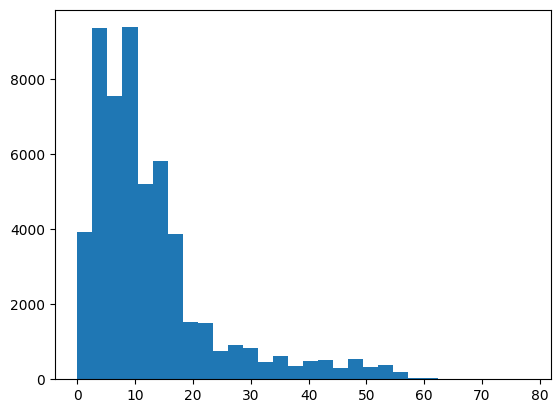

In [ ]:
plt.hist([len(s) for s in train_seq]+ [len(s) for s in test_seq],bins=30)
# X축 : 단어 수(토큰 개수)
# Ycnr : 문자의 개수
# 5~15단어 정도 사용이 많다.
# 최고점 : 5~8단어 정도인 문장이 제일 많다.

In [ ]:
max_len=15

def torch_pad_seq(sequences, maxlen, padding="post", truncatings="post"):
  features=[]
  for seq in sequences:
    # truncate(자르기)
    if len(seq)>maxlen:
      if truncatings=="post":
        seq=seq[:maxlen]
      else:
        seq=seq[-maxlen]
    # 패딩(채우기)
    pad_len=maxlen-len(seq)
    if pad_len >0:
      if padding=='post':
        seq=seq+[0]*pad_len
      else :
        seq[0] * pad_len+seq

    features.append(seq)

  return torch.tensor(features, dtype=torch.long)

In [ ]:
train_pad=torch_pad_seq(train_seq, maxlen=max_len)
train_pad

tensor([[   90,  1370,    13,  ...,    16,   430,    62],
        [   50,     4,    86,  ...,     0,     0,     0],
        [  629,    36, 10866,  ...,    26,     7,  1842],
        ...,
        [  340,    13,   197,  ...,     0,     0,     0],
        [ 1948,     2,    51,  ...,   123,     0,     0],
        [ 2395,  1962,    13,  ...,     0,     0,     0]])

In [ ]:
test_pad=torch_pad_seq(test_seq, maxlen=max_len)
test_pad

tensor([[1683,    7,  460,  ...,   96,  270,    0],
        [ 148,    4,   23,  ...,    0,    0,    0],
        [ 107,  993, 3491,  ...,    0,    0,    0],
        ...,
        [   2,   51,   67,  ...,    5,    0,    0],
        [ 382,    9,  299,  ...,   91,    0,    0],
        [ 485,   52,    0,  ...,    0,    0,    0]])

In [ ]:
# {'나는':3} =>{3:'나는}
reverse_word_index = {v: k for k, v in tokenizer.word2idx.items()}


def decode_sentence(sequence):
  # 텐서객체인지 확인
    if torch.is_tensor(sequence):
      # 리스트로 변환
        sequence = sequence.tolist()
        # if i!=0 : 패딩은 실제단어가 아니므로 제외시킴
    return ' '.join([reverse_word_index.get(i, '?') for i in sequence if i != 0])

print(decode_sentence(train_seq[2]))
print(train_documents[2])

순수하다 나오다 커다랗다 감동 과 아름답다 움 을 준 따뜻하다 영화 오랜 만 에 목 이 메다
['순수하다', '나오다', '커다랗다', '감동', '과', '아름답다', '움', '을', '준', '따뜻하다', '영화', '오랜', '만', '에', '목', '이', '메다']


In [ ]:
class LSTMClassfier(nn.Module):
  def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim):
    super().__init__()
    # 숫자로 된 단어 번호 -> 의미가 담긴 벡터로 바꾼다
    # 정수 인덱스를 입력받아 embedding_dim 크기의 실수 벡터로 바꿔준다
    self.embedding=nn.Embedding(vocab_size+1, embedding_dim)

    # lstm 기본: (seq, batch, feature)
    # batch_first=True(batch, seq, feature)
    self.lstm=nn.LSTM(embedding_dim, hidden_dim, batch_first=True, bidirectional=True)

    # BiLSTM이기 때문에 2배(정방향, 역방향 -> 입력크기 2배)
    self.fc1=nn.Linear(hidden_dim*2, 32)
    self.fc2=nn.Linear(32, output_dim)

    self.relu=nn.ReLU()
    self.sigmoid=nn.Sigmoid()


  def forward(self, x):
    # 숫자로 된 데이터들을 벡터로 바꾼다
    embedded=self.embedding(x)
    # 벡터를 LSTM이 읽는다.
    output,(hidden, cell)=self.lstm(embedded)

    # 1개층을 가진 양방향 (1*2)=2
    # hidden[-2]
    # hidden[-1]
    # (1*2, batch_size, hidden_dim)
    last_hidden=torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim =1)

    x=self.relu(self.fc1(last_hidden))
    x=self.sigmoid(self.fc2(x))
    return x


In [ ]:
model=LSTMClassfier(vocab_size=20000, embedding_dim=64, hidden_dim=64, output_dim=1)
model

LSTMClassfier(
  (embedding): Embedding(20001, 64)
  (lstm): LSTM(64, 64, batch_first=True, bidirectional=True)
  (fc1): Linear(in_features=128, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)

In [ ]:
from torch.utils.data import TensorDataset

In [ ]:
train_data=TensorDataset(torch.LongTensor(train_pad), torch.FloatTensor(train_labels))
test_data=TensorDataset(torch.LongTensor(test_pad), torch.FloatTensor(test_labels))

train_loader=DataLoader(train_data, batch_size=128, shuffle=True)
test_loader=DataLoader(test_data, batch_size=128)

In [ ]:
# 학습시커서 루프돌려서
# 시각화 정확도

In [ ]:
train_data=TensorDataset(torch.LongTensor(train_pad), torch.FloatTensor(train_labels))
test_data=TensorDataset(torch.LongTensor(test_pad), torch.FloatTensor(test_labels))

train_loader=DataLoader(train_data, batch_size=128, shuffle=True)
test_loader=DataLoader(test_data, batch_size=128)

In [ ]:
#손실함수 설정
bceloss=nn.BCELoss()
optimizer=optim.Adam(model.parameters(), lr=0.001)

In [ ]:
%%time
num_epochs = 30
history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}

for epoch in range(num_epochs):

    model.train()
    train_loss = 0
    correct = 0
    total = 0

    for inputs, labels in train_loader:


        # 그래디언트 초기화
        optimizer.zero_grad()

        # 순전파 (Forward)
        outputs = model(inputs).squeeze() # [batch, 1] -> [batch]
        loss = bceloss(outputs, labels)


        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        # 정확도 계산 (0.5 기준으로 0 또는 1 판단)
        predicted = (outputs > 0.5).float()
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_accuracy = correct / total
    avg_train_loss = train_loss / len(train_loader)


    model.eval()
    test_loss = 0
    correct = 0
    total = 0

    with torch.no_grad(): # 검증 시에는 기울기 계산 안 함 (메모리 절약)
        for inputs, labels in test_loader:

            outputs = model(inputs).squeeze()
            loss = bceloss(outputs, labels)

            test_loss += loss.item()
            predicted = (outputs > 0.5).float()
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    test_accuracy = correct / total
    avg_test_loss = test_loss / len(test_loader)

    # 기록 저장 (history)
    history['train_loss'].append(avg_train_loss)
    history['test_loss'].append(avg_test_loss)
    history['train_acc'].append(train_accuracy)
    history['test_acc'].append(test_accuracy)

    print(f'Epoch [{epoch+1}/{num_epochs}] '
          f'Loss: {avg_train_loss:.4f}, Acc: {train_accuracy:.4f} | '
          f'Val Loss: {avg_test_loss:.4f}, Val Acc: {test_accuracy:.4f}')

Epoch [1/30] Loss: 0.5531, Acc: 0.7036 | Val Loss: 0.4646, Val Acc: 0.7832
Epoch [2/30] Loss: 0.4221, Acc: 0.8028 | Val Loss: 0.4328, Val Acc: 0.7958
Epoch [3/30] Loss: 0.3629, Acc: 0.8368 | Val Loss: 0.4233, Val Acc: 0.8012
Epoch [4/30] Loss: 0.3126, Acc: 0.8634 | Val Loss: 0.4322, Val Acc: 0.8090
Epoch [5/30] Loss: 0.2652, Acc: 0.8891 | Val Loss: 0.4528, Val Acc: 0.8064
Epoch [6/30] Loss: 0.2156, Acc: 0.9128 | Val Loss: 0.4896, Val Acc: 0.8046
Epoch [7/30] Loss: 0.1694, Acc: 0.9336 | Val Loss: 0.5743, Val Acc: 0.7988
Epoch [8/30] Loss: 0.1311, Acc: 0.9515 | Val Loss: 0.6776, Val Acc: 0.8014
Epoch [9/30] Loss: 0.0990, Acc: 0.9644 | Val Loss: 0.8391, Val Acc: 0.7908
Epoch [10/30] Loss: 0.0785, Acc: 0.9720 | Val Loss: 0.9561, Val Acc: 0.7888
Epoch [11/30] Loss: 0.0635, Acc: 0.9767 | Val Loss: 1.0427, Val Acc: 0.7906
Epoch [12/30] Loss: 0.0513, Acc: 0.9809 | Val Loss: 1.1965, Val Acc: 0.7962
Epoch [13/30] Loss: 0.0419, Acc: 0.9841 | Val Loss: 1.3620, Val Acc: 0.7886
Epoch [14/30] Loss: 0

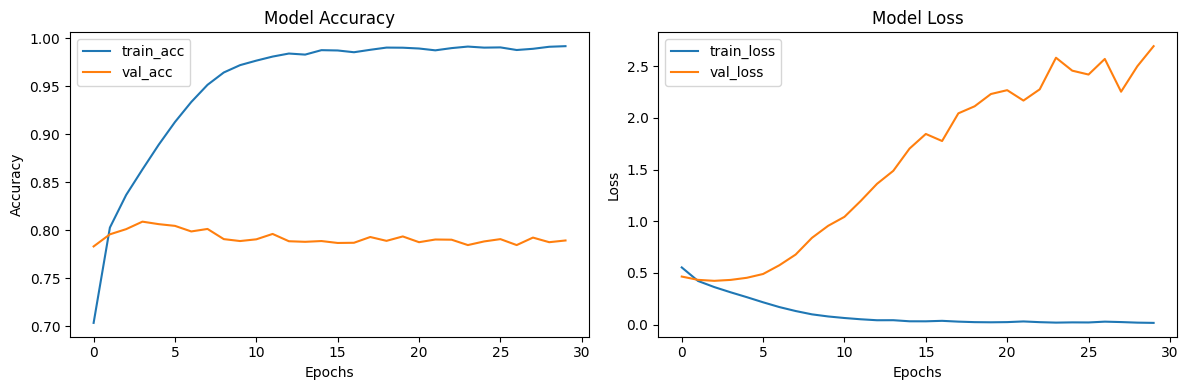

In [ ]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history['train_acc'])
ax1.plot(history['test_acc'])
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.set_title('Model Accuracy')
ax1.legend(['train_acc', 'val_acc'])


ax2.plot(history['train_loss'])
ax2.plot(history['test_loss'])
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.set_title('Model Loss')
ax2.legend(['train_loss', 'val_loss'])

plt.tight_layout() # 그래프 간격 자동 조절
plt.show()